# 📊 Assignment: Predicting 2024 Data Science Salaries Using Linear Regression

**Course**: Data Analytics with Python  
**Instructor**: Leonard Andrew Mesiera  
**Due Date**: October 22, 2025

## 🎯 Learning Objectives
By the end of this assignment, you will be able to:
- Load and explore a real-world dataset
- Prepare data for linear regression (feature engineering, encoding, cleaning)
- Train a simple linear regression model using `scikit-learn`
- Evaluate your model using metrics like R² and interpret results
- Make predictions for future years (e.g., 2024)

## 📁 Dataset
You are given the file: `Data Science Salary 2021 to 2023.csv`

This dataset contains salary information for data professionals from 2021 to 2023, including:
- `work_year`: The year the salary was recorded
- `experience_level`: EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `job_title`: e.g., Data Scientist, Data Analyst, etc.
- `salary_in_usd`: Salary converted to USD (this is your target variable)
- Other useful columns: `employment_type`, `company_location`, `company_size`

Your goal: **Predict average salaries for 2024** using linear regression.

## 🛠️ Part 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

dss = pd.read_csv('Data Science Salary 2021 to 2023.csv')

dss.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [2]:
# Basic info
dss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

<h5>1. How many unique job titles are there?</h5>

<h5>2. What is the average salary (`salary_in_usd`) per `work_year`?</h5>

<h5>3. Create a bar plot showing average salary by `experience_level`.</h5>

> 💡 Tip: Use `groupby()` and `mean()`.

<h3>1. How many unique job titles are there?</h3>

In [3]:
num_job_titles = dss['job_title'].nunique()
print(f"Number of unique job titles: {num_job_titles}")

Number of unique job titles: 93


<h3>2. What is the average salary (salary_in_usd) per work_year?</h3>

In [4]:
avg_by_year = dss.groupby('work_year')['salary_in_usd'].mean().reset_index()
print(avg_by_year)

   work_year  salary_in_usd
0       2020   92302.631579
1       2021   94087.208696
2       2022  133379.510804
3       2023  148954.558413


<h3>3. Create a bar plot showing average salary by experience_level.</h3>

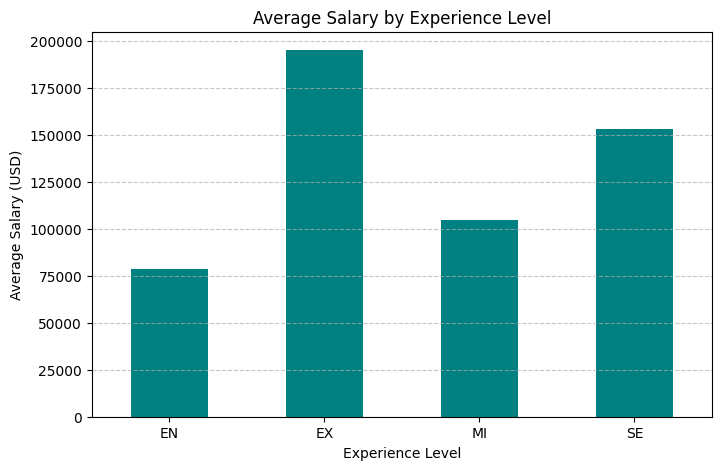

In [5]:
plt.figure(figsize=(8, 5))
dss.groupby('experience_level')['salary_in_usd'].mean().plot(kind='bar', color='teal')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🧹 Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [6]:
# Encode experience_level
le = LabelEncoder()
dss['exp_encoded'] = le.fit_transform(dss['experience_level'])

# Define features and target
X = dss[['work_year', 'exp_encoded']]
y = dss['salary_in_usd']

## 📈 Part 4: Train a Linear Regression Model

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.2f}")
print(f"RMSE: ${rmse:,.2f}")

R² Score: 0.15
RMSE: $59,164.82


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [8]:
# Prepare 2024 data for all experience levels
future = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'exp_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})

# Predict
pred_2024 = model.predict(future)

# Display
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': pred_2024
})
results['Predicted 2024 Salary (USD)'] = results['Predicted 2024 Salary (USD)'].map('${:,.0f}'.format)
print(results)

  Experience Level Predicted 2024 Salary (USD)
0            Entry                    $111,695
1              Mid                    $131,967
2           Senior                    $152,240
3        Executive                    $172,512


## 📝 Part 6: Reflection (Answer in a Markdown Cell)

<h5>1. Does your model make reasonable predictions? Why or why not?</h5>

> To a degree, it does. The predictions follows a trend with experience, which makes sense. But they’re estimates—real salaries depend on many factors the model ignores, like job title or company.
   
<h5>2. What are the limitations of using only `work_year` and `experience_level`?</h5>

> The setup oversimplifies reality. Two Senior Data Scientists, one in a startup, one in a tech giant, can earn very different salaries. Without location, role, or company size, the model can’t capture these differences.

<h5>3. How could you improve this model? (Think: more features, better encoding, etc.)</h5>

> I guess, adding more features like job_title and company_location. I think it is also worth trying tree-based models for non-linear patterns.

<h5>4. Why is "R² not enough" to trust your predictions?</h5>
   
> R² only measures how well the model fits the training data. A low R² (like 0.15) means the model misses most of the real variation. It also doesn’t tell prediction bias.

<br>

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀